In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import uniform, randint
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/results/outputs/Group Pipeline (Frequency).csv')

In [3]:
# 3. DEFINE X (FEATURES) AND y (TARGET)
y = df['Sales']
X = df.drop([
    'Game Title', 'Sales', 'North American Sales', 
    'Japanese Sales', 'EU Sales', 'Other Sales', 'Game Quality'
], axis=1)

In [4]:
# 4. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (14053, 13)
Test set shape: (3514, 13)


In [5]:
# 5. HYPERPARAMETER TUNING
print("\nStarting Hyperparameter Tuning for XGBoost...")
param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.7, 0.3), # 0.3 is range, so 0.7 to 1.0
    'colsample_bytree': uniform(0.7, 0.3)
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    xgb, 
    param_distributions=param_dist, 
    n_iter=25, 
    cv=5, 
    random_state=42, 
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
print(f"Best parameters found: {random_search.best_params_}")


Starting Hyperparameter Tuning for XGBoost...
Best parameters found: {'colsample_bytree': np.float64(0.7076257380232285), 'learning_rate': np.float64(0.042367428097991336), 'max_depth': 9, 'n_estimators': 451, 'subsample': np.float64(0.890923123379134)}


In [6]:
# 6. MAKE PREDICTIONS AND EVALUATE
y_pred = best_xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Tuned XGBoost Final Results ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("-----------------------------------")


--- Tuned XGBoost Final Results ---
R-squared (R²): 0.6601
Mean Absolute Error (MAE): 0.0089
Root Mean Squared Error (RMSE): 0.0239
-----------------------------------


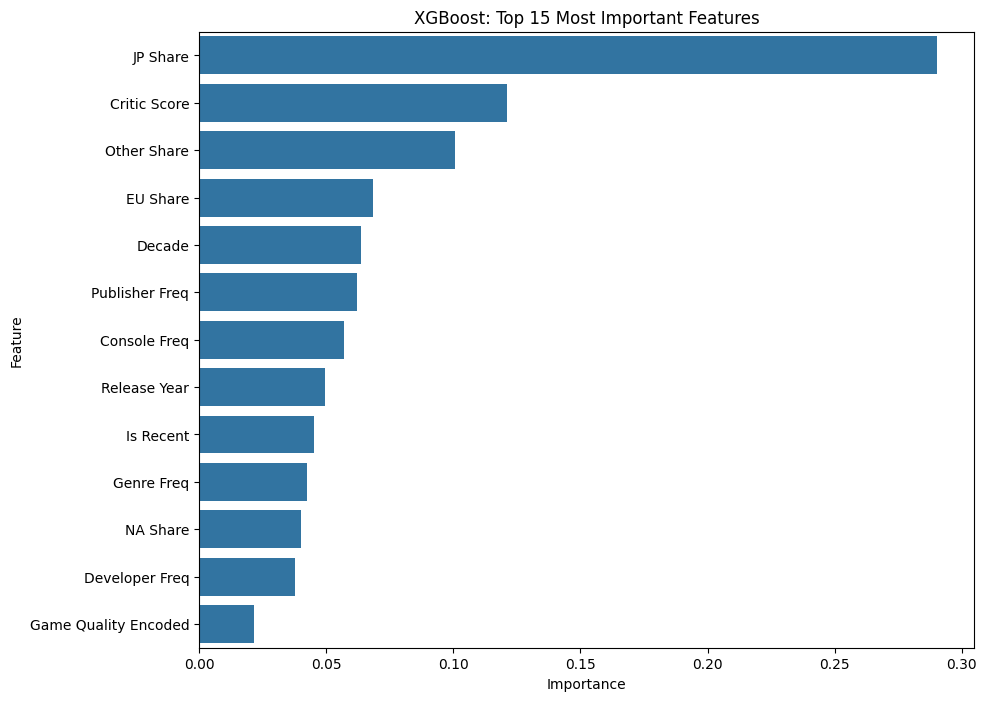

In [7]:
# 7. VISUALIZATION 1: FEATURE IMPORTANCE
importances = best_xgb.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('XGBoost: Top 15 Most Important Features')
plt.show()

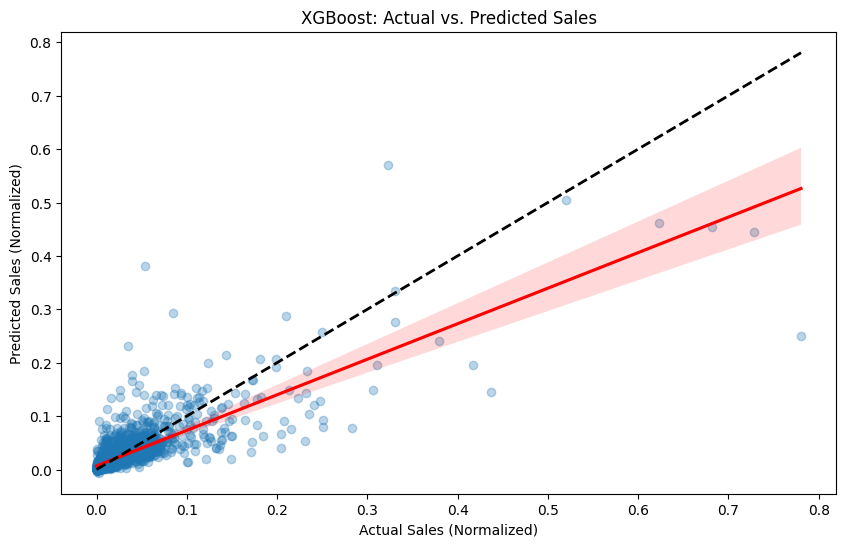

In [8]:
# 8. VISUALIZATION 2: ACTUAL VS. PREDICTED
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('XGBoost: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales (Normalized)')
plt.ylabel('Predicted Sales (Normalized)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()